# Exploration des données — Système de recommandation

Dataset : MovieLens (movies.csv, ratings.csv, tags.csv, links.csv)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')
tags = pd.read_csv('../data/tags.csv')
links = pd.read_csv('../data/links.csv')

print(f"movies : {movies.shape}")
print(f"ratings : {ratings.shape}")
print(f"tags : {tags.shape}")
print(f"links : {links.shape}")

movies : (9742, 3)
ratings : (100836, 4)
tags : (3683, 4)
links : (9742, 3)


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Vue d'ensemble du fichier principal : ratings

In [5]:
ratings.info()

print(f"\nValeurs manquantes : {ratings.isnull().sum().sum()}")

print(f"\nNombre d'utilisateurs uniques : {ratings['userId'].nunique()}")
print(f"Nombre de films uniques notés : {ratings['movieId'].nunique()}")
print(f"Nombre total de notes : {len(ratings)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Valeurs manquantes : 0

Nombre d'utilisateurs uniques : 610
Nombre de films uniques notés : 9724
Nombre total de notes : 100836


## Distribution des notes

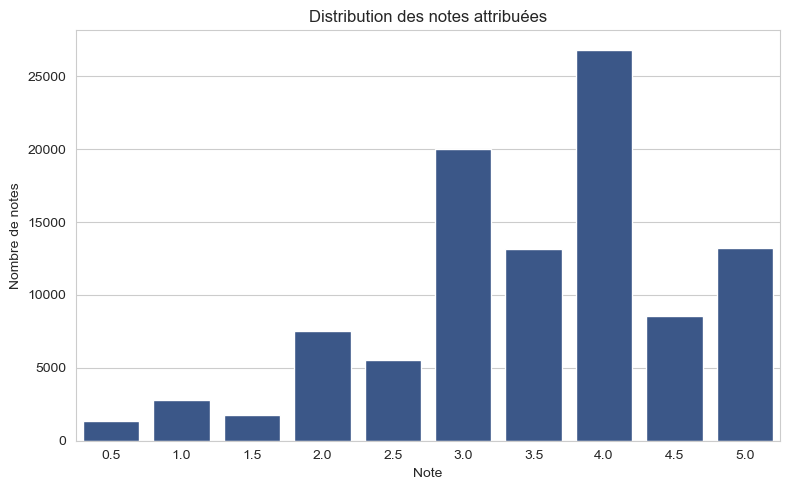

Note moyenne globale : 3.50
Note médiane : 3.5


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ratings, x='rating', color='#2E5395')
plt.title('Distribution des notes attribuées')
plt.xlabel('Note')
plt.ylabel('Nombre de notes')
plt.tight_layout()
plt.savefig('../outputs/ratings_distribution.png', dpi=150)
plt.show()

print(f"Note moyenne globale : {ratings['rating'].mean():.2f}")
print(f"Note médiane : {ratings['rating'].median()}")

## Nombre de notes par utilisateur et par film

Point clé pour un système de recommandation : la distribution est presque toujours très inégale (loi de puissance) — quelques utilisateurs/films très actifs, une longue traîne de contributions rares.

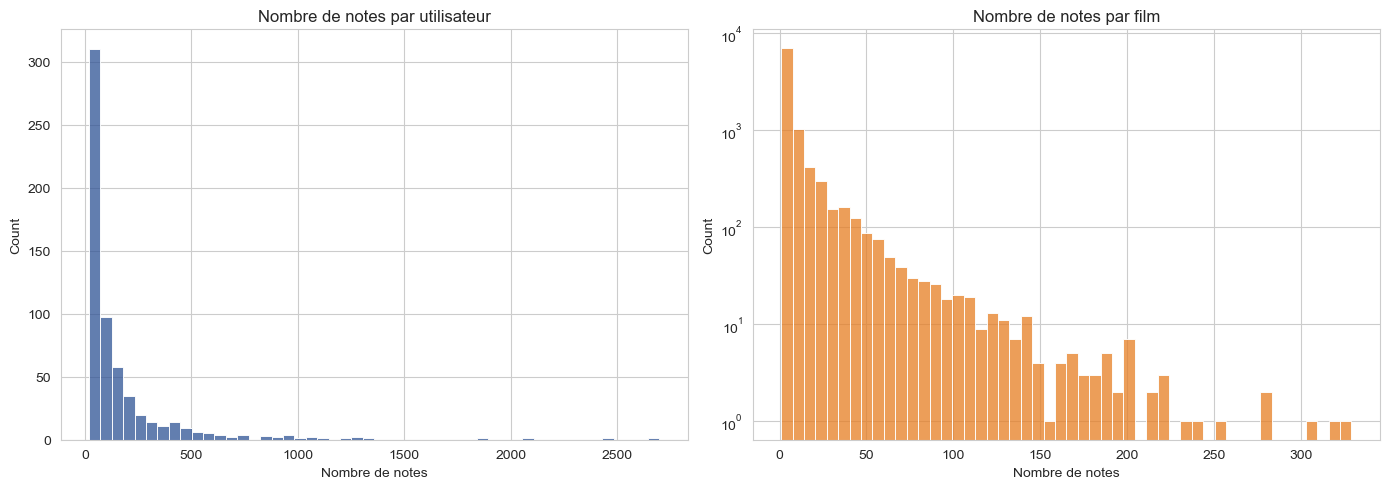

Médiane de notes par utilisateur : 70.5
Médiane de notes par film : 3.0

Top 5 utilisateurs les plus actifs :
userId
414    2698
599    2478
474    2108
448    1864
274    1346
dtype: int64

Top 5 films les plus notés :
  Forrest Gump (1994) : 329 notes
  Shawshank Redemption, The (1994) : 317 notes
  Pulp Fiction (1994) : 307 notes
  Silence of the Lambs, The (1991) : 279 notes
  Matrix, The (1999) : 278 notes


In [7]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ratings_per_user, bins=50, ax=axes[0], color='#2E5395')
axes[0].set_title('Nombre de notes par utilisateur')
axes[0].set_xlabel('Nombre de notes')

sns.histplot(ratings_per_movie, bins=50, ax=axes[1], color='#E67E22')
axes[1].set_title('Nombre de notes par film')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/ratings_per_user_movie.png', dpi=150)
plt.show()

print(f"Médiane de notes par utilisateur : {ratings_per_user.median()}")
print(f"Médiane de notes par film : {ratings_per_movie.median()}")
print(f"\nTop 5 utilisateurs les plus actifs :\n{ratings_per_user.sort_values(ascending=False).head()}")
print(f"\nTop 5 films les plus notés :")
top_movies = ratings_per_movie.sort_values(ascending=False).head()
for movie_id, count in top_movies.items():
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"  {title} : {count} notes")

## Sparsité de la matrice utilisateur-film

Un des enjeux centraux des systèmes de recommandation : la matrice utilisateur x film est presque toujours très creuse (la plupart des utilisateurs n'ont noté qu'une infime fraction des films disponibles).

In [8]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Nombre d'utilisateurs : {n_users}")
print(f"Nombre de films : {n_movies}")
print(f"Notes possibles (utilisateurs x films) : {possible_ratings:,}")
print(f"Notes réellement présentes : {n_ratings:,}")
print(f"\n→ Sparsité de la matrice : {sparsity*100:.2f}%")
print(f"→ Seulement {100-sparsity*100:.2f}% des cases de la matrice utilisateur-film sont remplies")

Nombre d'utilisateurs : 610
Nombre de films : 9724
Notes possibles (utilisateurs x films) : 5,931,640
Notes réellement présentes : 100,836

→ Sparsité de la matrice : 98.30%
→ Seulement 1.70% des cases de la matrice utilisateur-film sont remplies


## Répartition par genre

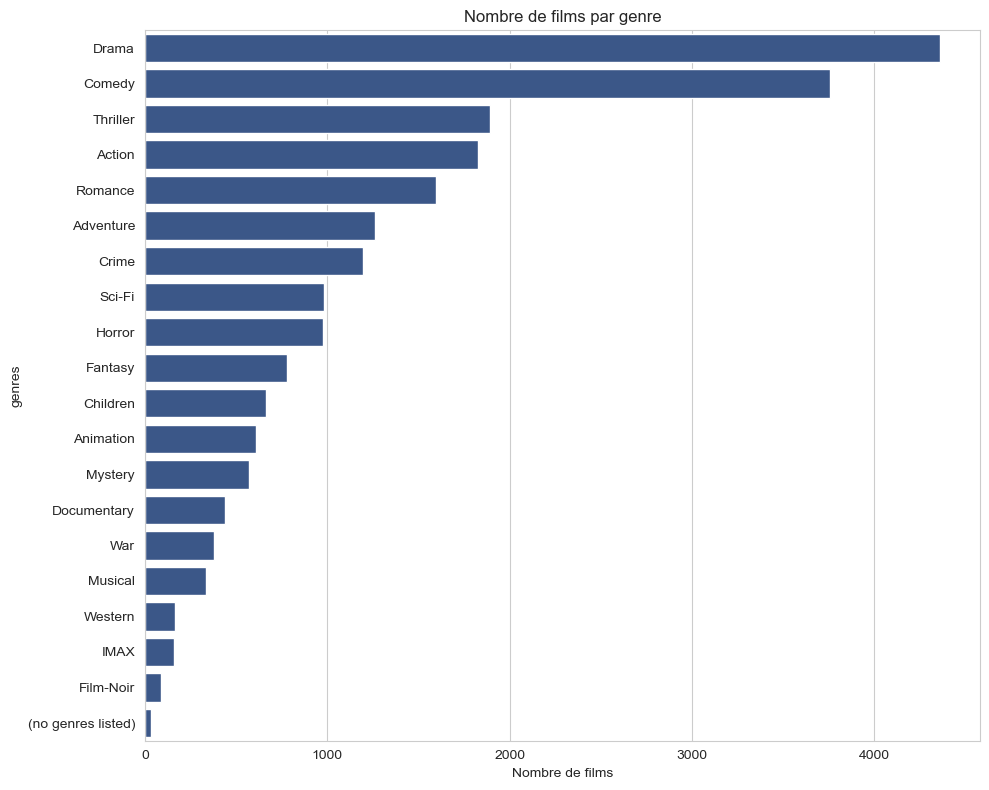

In [9]:
# Chaque film peut avoir plusieurs genres séparés par '|'
genres_split = movies['genres'].str.split('|').explode()
genre_counts = genres_split.value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='#2E5395')
plt.title('Nombre de films par genre')
plt.xlabel('Nombre de films')
plt.tight_layout()
plt.savefig('../outputs/genres_distribution.png', dpi=150)
plt.show()

## Aperçu du fichier tags (optionnel, non utilisé pour le filtrage collaboratif)

In [10]:
print(f"Nombre de tags : {len(tags)}")
print(f"Nombre d'utilisateurs ayant taggé : {tags['userId'].nunique()}")
tags.head()

Nombre de tags : 3683
Nombre d'utilisateurs ayant taggé : 58


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
